# Filtering and T cell removal of Netskar et al., data

This script performs filtering, dataset label refinement, patient ID standardization, and T cell removal on the Netskar et al., pan-cancer NK cell dataset.

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

In [2]:
adata= sc.read_h5ad('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/malmberg_data/adata_all_nk_after_mapping_v4.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 90320 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'patient'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [5]:
#creating patientID from malmberg patient column
adata.obs['patient_ID'] = adata.obs['patient'].astype(str)

In [7]:
# Rename the column 'patient' to 'Malmberg_patient'
adata.obs.rename(columns={'patient': 'Malmberg_patient'}, inplace=True)
print("Column renamed successfully.")

Column renamed successfully.


*Filtering - non 10x*

In [9]:
filter_condition = ~adata.obs['dataset'].isin(['zilionis', 'xu_GSE180286', 'xu_GSE158399'])
adata= adata[filter_condition].copy()

*Removal of normal brain samples - lymphocytes clustered with neurons- mainly paper focused on neurons*

In [10]:
# Subset the AnnData object to exclude rows where 'source' equals 'brain_normal'
adata = adata[adata.obs['source'] != 'brain_normal']

In [11]:
# Count rows where 'source' equals 'brain_normal'
brain_normal_count = (adata.obs['source'] == 'brain_normal').sum()
print(f"Number of 'brain_normal' entries: {brain_normal_count}")

Number of 'brain_normal' entries: 0


In [12]:
adata

View of AnnData object with n_obs × n_vars = 88724 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

*Checking if patients are with same name in multiple datasets*

In [14]:
# Group by patient_ID and aggregate the unique dataset categories
patient_dataset_details = adata.obs.groupby('patient_ID')['dataset'].unique()

# Filter for patient_IDs present in more than one dataset category
patients_in_multiple_datasets = patient_dataset_details[patient_dataset_details.apply(len) > 1]

# Display results
print("Patient and their associated datasets:")
for patient_id, datasets in patients_in_multiple_datasets.items():
    print(f"{patient_id}: {list(datasets)}")

Patient and their associated datasets:
1: ['lambrechts', 'he']
2: ['lambrechts', 'he']
3: ['lambrechts', 'he']
4: ['lambrechts', 'he']
5: ['lambrechts', 'he']
D11: ['tuong', 'bhat']
D4: ['tuong', 'bhat']
D5: ['tuong', 'bhat']


In [15]:
adata.obs.groupby('dataset')['patient_ID'].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/2565429372.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('dataset')['patient_ID'].nunique()


dataset
GSE212966          6
abdelfattah       15
amir               5
bassez            31
bhaduri            4
bhat               8
bischoff          20
chan              18
chen              20
chen_GSE212966     3
cillo              4
couturier          9
crinier            3
damsky             2
goeveia           15
goswami            3
he                16
heidegger          8
johnson            4
kim               22
lambrechts        15
leader            51
leader_cite       20
leblanc            2
lee               31
lin                5
liu                6
malm               2
mathewson          5
mirizio            3
neftel             5
pal               28
peng              16
pombo             11
ravi               7
richards           6
rindler            4
smalley            8
steele            16
tuong              9
wang2019           1
wang2020           1
wu                47
xie                4
xue                9
yang               2
zhang              3
zhou 

In [16]:
print(adata.obs['patient_ID'].nunique())

533


*LAMBRECHTS - Updating patients in lambrechts datset to avoid confusion with He dataset*

In [18]:
#Update the 'patient_ID' for the rows where 'dataset' == 'lambrechts' and p_1_lambrechts... to avoid confusion with he

In [19]:
# Temporarily convert the 'patient_ID' column to string type to allow modification
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Update the 'patient_ID' for the rows where 'dataset' == 'lambrechts' and 'patient_ID' is between 1 and 8
mask = adata.obs['dataset'] == 'lambrechts'

for i in range(1, 9):
    adata.obs.loc[mask & (adata.obs['patient_ID'] == str(i)), 'patient_ID'] = f"p_{i}_lambrechts"

# convert back to Categorical if needed
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype('category')

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/1451784525.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)


In [23]:
adata_lambrechts = adata[adata.obs['dataset'] == 'lambrechts']
adata_lambrechts.obs["patient_ID"].unique()

['2_lambrechts', '3_lambrechts', '4_lambrechts', '5_lambrechts', '7_lambrechts', ..., 'p_4_lambrechts', 'p_5_lambrechts', 'p_7_lambrechts', 'p_8_lambrechts', 'p_6_lambrechts']
Length: 15
Categories (15, object): ['2_lambrechts', '3_lambrechts', '4_lambrechts', '5_lambrechts', ..., 'p_5_lambrechts', 'p_6_lambrechts', 'p_7_lambrechts', 'p_8_lambrechts']

In [24]:
adata_lambrechts.obs["Malmberg_patient"].unique()

['2_lambrechts', '3_lambrechts', '4_lambrechts', '5_lambrechts', '7_lambrechts', ..., '4', '5', '7', '8', '6']
Length: 15
Categories (15, object): ['1', '2', '2_lambrechts', '3', ..., '7', '7_lambrechts', '8', '8_lambrechts']

In [25]:
adata_bhat = adata[adata.obs['dataset'] == 'bhat']
adata_bhat.obs["patient_ID"].unique()

['D1', 'D2', 'D3', 'D4', 'D5', 'D6-D10_Pool_CMG', 'D6-D10_Pool_HN', 'D11']
Categories (8, object): ['D1', 'D11', 'D2', 'D3', 'D4', 'D5', 'D6-D10_Pool_CMG', 'D6-D10_Pool_HN']

*BHAT - Added suffix _bhat to all patient IDs & removal of pooled samples in bhat dataset*

In [26]:
# Ensure patient_ID is string
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Create a mask for rows where 'dataset' is 'bhat'
mask_bhat = adata.obs['dataset'] == 'bhat'

# Append '_bhat' to patient_ID for bhat samples
adata.obs.loc[mask_bhat, 'patient_ID'] = adata.obs.loc[mask_bhat, 'patient_ID'].apply(lambda x: f"{x}_bhat")

# Remove pooled samples only from 'bhat' dataset
mask_pool_bhat = ~(mask_bhat & adata.obs['patient_ID'].str.contains('Pool'))
adata = adata[mask_pool_bhat].copy()  # keeps everything except pooled 'bhat'

# Convert patient_ID back to category if needed
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype('category')

In [28]:
adata_bhat = adata[adata.obs['dataset'] == 'bhat']
adata_bhat.obs["patient_ID"].unique()

['D1_bhat', 'D2_bhat', 'D3_bhat', 'D4_bhat', 'D5_bhat', 'D11_bhat']
Categories (6, object): ['D11_bhat', 'D1_bhat', 'D2_bhat', 'D3_bhat', 'D4_bhat', 'D5_bhat']

In [29]:
adata_bhat.obs["Malmberg_patient"].unique()

['D1', 'D2', 'D3', 'D4', 'D5', 'D11']
Categories (6, object): ['D1', 'D2', 'D3', 'D4', 'D5', 'D11']

*LEADER - Removing suffix _leader in leader and leader_cite datasets to map amp_batch_ID to patientID in these datasets using a reference excel file*

In [30]:
# Convert to string for safe modification
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Modify 'leader'
condition_leader = adata.obs['dataset'] == 'leader'
adata.obs.loc[condition_leader, 'patient_ID'] = adata.obs.loc[condition_leader, 'patient_ID'].str.replace('_leader', '', regex=False)

# Modify 'leader_cite'
condition_leader_cite = adata.obs['dataset'] == 'leader_cite'
adata.obs.loc[condition_leader_cite, 'patient_ID'] = adata.obs.loc[condition_leader_cite, 'patient_ID'].str.replace('_leader', '', regex=False)

# Convert back to category if needed
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype('category')

In [31]:
# Specify the file path
file_path = "/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/malmberg_data/csv/leader_pan_cancer_profiling_patient.xlsx"

In [32]:
# Read the 'sample_table' sheet from the Excel file
sample_data = pd.read_excel(file_path, sheet_name='sample_table', header=0)

# Extract the 2nd and 3rd columns (indexing starts at 0, so columns 1 and 2)
second_and_third_columns = sample_data.iloc[:, 1:3]  # Select columns 2 and 3

# Display the extracted data
print("Second and Third Columns:")
print(second_and_third_columns.head())

Second and Third Columns:
  patient_ID_leader  amp_batch_ID
0               558            36
1               564            37
2               564            38
3               569            39
4               569            40


In [33]:
# Create a mapping dictionary from the Excel data
# Convert both 'sample_ID' and 'patient_ID' to string
mapping_dict = dict(zip(second_and_third_columns['amp_batch_ID'].astype(str), second_and_third_columns['patient_ID_leader'].astype(str)))

In [34]:
# Apply the mapping only to rows where 'dataset' is 'leader'
condition = adata.obs['dataset'] == 'leader'

In [35]:
# Convert patient_ID to string to avoid Categorical errors
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Apply mapping only to the condition (e.g., 'leader')
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].map(mapping_dict)

# Convert back to category
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype('category')

In [36]:
adata.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,HALLMARK_MTORC1_SIGNALING_auc,HALLMARK_NOTCH_SIGNALING_auc,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID
AAACCTGAGTGTCCAT_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1345.0,725.0,2.304833,401,0,...,0.034939,0.008891,0.098046,0.041626,0.005439,KIR+_PBMC,CD56dim,reference,malm1,malm1
AAACCTGCACATGGGA_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,2108.0,884.0,2.182163,401,0,...,0.043463,0.055352,0.106493,0.033480,0.000000,NKG2A+_PBMC,CD56dim,reference,malm1,malm1
AAACCTGCACCTCGGA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1821.0,853.0,2.471170,401,0,...,0.083511,0.020572,0.093315,0.054942,0.000000,KIR+_PBMC,CD56dim,reference,malm1,malm1
AAACCTGGTTGAGTTC_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,1294.0,753.0,2.086553,401,0,...,0.060954,0.020964,0.126957,0.041032,0.018933,NKG2A+_PBMC,CD56dim,reference,malm1,malm1
AAACCTGTCACCGTAA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1637.0,831.0,1.710446,401,0,...,0.054450,0.053217,0.122799,0.035483,0.013773,KIR+_PBMC,CD56dim,reference,malm1,malm1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rGBM-04-4_TAAGTCGGTTCTTGCC-1-0-1_abdelfattah_rGBM-04,rGBM-04,rGBM-04,TiCD56bright,abdelfattah,glioblastoma,2693.0,1184.0,3.564798,843,0,...,0.073805,0.008020,0.079250,0.028977,0.000000,TiCD56bright_glioblastoma,CD56bright,tumor,rGBM-04_abdelfattah,rGBM-04_abdelfattah
rGBM-05-2_ATATCCTAGTCATACC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,1946.0,1059.0,1.593011,844,0,...,0.044673,0.015037,0.109973,0.055180,0.026290,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah
rGBM-05-2_CCCTCAACATAGACTC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,2335.0,1371.0,2.655246,844,0,...,0.041763,0.026063,0.084738,0.038762,0.006032,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah
rGBM-05-3_AGGAAATCATTCATCT-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,5610.0,1888.0,8.039216,844,0,...,0.077826,0.000000,0.129551,0.034727,0.000000,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah


In [37]:
adata_l= adata[adata.obs['dataset'] == 'leader']

In [38]:
adata_l

View of AnnData object with n_obs × n_vars = 9753 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [39]:
adata_l.obs['patient_ID'].unique()

['370', '371', '377', '378', '403', ..., '558', '571', '338', '725', '800']
Length: 28
Categories (28, object): ['338', '370', '371', '377', ..., '714', '725', '729', '800']

In [40]:
adata_l.obs['Malmberg_patient'].unique()

['1_leader', '3_leader', '5_leader', '7_leader', '10_leader', ..., '231_leader', '292_leader', '308_leader', '309_leader', '668_leader']
Length: 51
Categories (51, object): ['1_leader', '2_leader', '3_leader', '4_leader', ..., '307_leader', '308_leader', '309_leader', '668_leader']

In [41]:
adata_l.obs['patient_ID'].nunique()

28

In [42]:
# Apply the mapping only to rows where 'dataset' is 'leader'
condition = adata.obs['dataset'] == 'leader_cite'

In [43]:

# Convert patient_ID to string to avoid Categorical errors
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Apply mapping only to the condition (e.g., 'leader')
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].map(mapping_dict)

# convert back to category
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype('category')

In [44]:
adata_lcite= adata[adata.obs['dataset'] == 'leader_cite']

In [45]:
adata_lcite.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,HALLMARK_MTORC1_SIGNALING_auc,HALLMARK_NOTCH_SIGNALING_auc,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID
AAAGCAAGTCATCCCT-1-0_leader_cite_48_leader,48_leader,0_leader,TrCD56dim,leader_cite,lung_normal,1463.0,960.0,4.778157,0,0,...,0.059275,0.019046,0.176123,0.029304,0.002824,TrCD56dim_lung_normal,CD56dim,reference,48_leader,581
AAAGTAGGTCTAGCCG-1-0_leader_cite_48_leader,48_leader,0_leader,TrCD56dim,leader_cite,lung_normal,567.0,425.0,4.216867,0,0,...,0.037244,0.050558,0.089730,0.040372,0.027371,TrCD56dim_lung_normal,CD56dim,reference,48_leader,581
AACTCTTCACGTTGGC-1-0_leader_cite_48_leader,48_leader,0_leader,TrCD56dim,leader_cite,lung_normal,529.0,386.0,2.955083,0,0,...,0.062954,0.055657,0.111563,0.032879,0.034972,TrCD56dim_lung_normal,CD56dim,reference,48_leader,581
AAGTCTGGTTCAACCA-1-0_leader_cite_48_leader,48_leader,0_leader,TrCD56dim,leader_cite,lung_normal,829.0,593.0,2.895323,0,0,...,0.067408,0.009371,0.154564,0.042086,0.027232,TrCD56dim_lung_normal,CD56dim,reference,48_leader,581
ACACTGATCAGGCCCA-1-0_leader_cite_48_leader,48_leader,0_leader,TrCD56dim,leader_cite,lung_normal,513.0,363.0,4.396985,0,0,...,0.054472,0.035478,0.135494,0.019073,0.038494,TrCD56dim_lung_normal,CD56dim,reference,48_leader,581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCCTAGAGTGGTCCC-1-19_leader_cite_348_leader,348_leader,19_leader,TiCD56bright,leader_cite,lung_tumor,2109.0,837.0,3.651020,301,0,...,0.032683,0.013642,0.099128,0.034482,0.002685,TiCD56bright_lung_tumor,CD56bright,tumor,348_leader,706
TACTTGTGTCAGAGGT-1-19_leader_cite_348_leader,348_leader,19_leader,TiCD56bright,leader_cite,lung_tumor,2234.0,1069.0,2.417189,301,0,...,0.067800,0.098980,0.121730,0.040943,0.050244,TiCD56bright_lung_tumor,CD56bright,tumor,348_leader,706
TCACAAGCAGTAAGCG-1-19_leader_cite_348_leader,348_leader,19_leader,TiCD56dim,leader_cite,lung_tumor,2768.0,1086.0,3.468208,301,0,...,0.040311,0.058229,0.143472,0.035261,0.013912,TiCD56dim_lung_tumor,CD56dim,tumor,348_leader,706
TCGCGTTAGTAGCGGT-1-19_leader_cite_348_leader,348_leader,19_leader,TiCD56bright,leader_cite,lung_tumor,2590.0,995.0,1.891892,301,0,...,0.076161,0.034432,0.086393,0.049104,0.017364,TiCD56bright_lung_tumor,CD56bright,tumor,348_leader,706


In [48]:
adata_lcite.obs['patient_ID'].unique()

['581', '584', '593', '596', '630', '626', '695', '706']
Categories (8, object): ['581', '584', '593', '596', '626', '630', '695', '706']

In [49]:
adata_lcite.obs['Malmberg_patient'].unique()

['48_leader', '51_leader', '52_leader', '53_leader', '54_leader', ..., '345_leader', '346_leader', '347_leader', '348_leader', '92_leader']
Length: 20
Categories (20, object): ['48_leader', '51_leader', '52_leader', '53_leader', ..., '345_leader', '346_leader', '347_leader', '348_leader']

In [50]:
adata_l.obs['patient_ID'].unique()

['370', '371', '377', '378', '403', ..., '558', '571', '338', '725', '800']
Length: 28
Categories (28, object): ['338', '370', '371', '377', ..., '714', '725', '729', '800']

*BISCHOFF - Unified Tumor-normal paired samples had different name formats into unique patient ID*

In [51]:
# Convert patient_ID to string to safely modify it
adata.obs['patient_ID'] = adata.obs['patient_ID'].astype(str)

# Create condition for 'bischoff' dataset
condition = adata.obs['dataset'] == 'bischoff'

# Update entries ending with 't' (e.g., p018t → p018_bischoff)
condition_t = adata.obs['patient_ID'].str.endswith('t')
adata.obs.loc[condition & condition_t, 'patient_ID'] = adata.obs.loc[condition & condition_t, 'patient_ID'].str.replace(
    r'(p\d{3})t$', r'\1_bischoff', regex=True
)

# Update entries ending with 'n_bischoff' (e.g., p018n_bischoff → p018_bischoff)
condition_n = adata.obs['patient_ID'].str.endswith('n_bischoff')
adata.obs.loc[condition & condition_n, 'patient_ID'] = adata.obs.loc[condition & condition_n, 'patient_ID'].str.replace(
    r'(p\d{3})n_bischoff$', r'\1_bischoff', regex=True
)

In [52]:
adata_bischoff = adata[adata.obs['dataset'] == 'bischoff']
adata_bischoff.obs["patient_ID"].unique()

array(['p018_bischoff', 'p019_bischoff', 'p027_bischoff', 'p028_bischoff',
       'p029_bischoff', 'p030_bischoff', 'p031_bischoff', 'p032_bischoff',
       'p033_bischoff', 'p034_bischoff', 'p024_bischoff', 'p023_bischoff'],
      dtype=object)

In [53]:
adata_bischoff.obs["Malmberg_patient"].unique()

['p018n_bischoff', 'p019n_bischoff', 'p027n_bischoff', 'p028n_bischoff', 'p029n_bischoff', ..., 'p018t', 'p032t', 'p023t', 'p031t', 'p030t']
Length: 20
Categories (20, object): ['p018n_bischoff', 'p018t', 'p019n_bischoff', 'p019t', ..., 'p033n_bischoff', 'p033t', 'p034n_bischoff', 'p034t']

*CHAN ->Removed _chan suffix to unify tumor and normal samples under unique patient ID*

In [54]:
# Apply transformation when the 'dataset' column is 'chan'
condition = adata.obs['dataset'] == 'chan'

# Modify patient_ID by removing '_chan' suffix
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].str.replace(r'(RU\d{3})_chan$', r'\1', regex=True)

In [55]:
adata_chan = adata[adata.obs['dataset'] == 'chan']
adata_chan.obs["patient_ID"].unique()

array(['RU675', 'RU682', 'RU684', 'RU685', 'RU661', 'RU676', 'RU1038',
       'RU1057', 'RU1061', 'RU1128', 'RU1134', 'RU1135', 'RU1137',
       'RU1170g', 'RU1262C', 'RU1271'], dtype=object)

In [56]:
adata_chan.obs["Malmberg_patient"].unique()

['RU675_chan', 'RU682_chan', 'RU684_chan', 'RU685_chan', 'RU661', ..., 'RU1135', 'RU1137', 'RU1170g', 'RU1262C', 'RU1271']
Length: 18
Categories (18, object): ['RU661', 'RU675', 'RU675_chan', 'RU676', ..., 'RU1137', 'RU1170g', 'RU1262C', 'RU1271']

*GOEVEIA - Removed _goeveia suffix to unify tumor and normal samples under unique patient ID*

In [57]:
# Apply transformation when the 'dataset' column is 'goeveia'
condition = adata.obs['dataset'] == 'goeveia'

# Modify patient_ID by removing '_goeveia' suffix
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].str.replace(r'(patient_\d{2})_goeveia$', r'\1', regex=True)


In [58]:
adata_goeveia = adata[adata.obs['dataset'] == 'goeveia']
adata_goeveia.obs["patient_ID"].unique()

array(['patient_40', 'patient_41', 'patient_42', 'patient_43',
       'patient_45', 'patient_46', 'patient_50', 'patient_32'],
      dtype=object)

In [59]:
adata_goeveia.obs["Malmberg_patient"].unique()

['patient_40_goeveia', 'patient_41_goeveia', 'patient_42_goeveia', 'patient_43_goeveia', 'patient_45_goeveia', ..., 'patient_42', 'patient_43', 'patient_45', 'patient_46', 'patient_50']
Length: 15
Categories (15, object): ['patient_32', 'patient_40', 'patient_40_goeveia', 'patient_41', ..., 'patient_46', 'patient_46_goeveia', 'patient_50', 'patient_50_goeveia']

In [60]:
adata_goeveia.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,HALLMARK_MTORC1_SIGNALING_auc,HALLMARK_NOTCH_SIGNALING_auc,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID
AAACCTGAGGCCGAAT.2.NEC_goeveia_patient_40,patient_40,patient_40_goeveia,TrCD56dim,goeveia,lung_normal,816.0,581.0,2.786885,413,0,...,0.066234,0.011506,0.105332,0.022471,0.028138,TrCD56dim_lung_normal,CD56dim,reference,patient_40_goeveia,patient_40
AAGACCTTCTTGTATC.2.NEC_goeveia_patient_40,patient_40,patient_40_goeveia,TrCD56dim,goeveia,lung_normal,1373.0,873.0,3.170290,413,0,...,0.030370,0.019177,0.164979,0.031529,0.032148,TrCD56dim_lung_normal,CD56dim,reference,patient_40_goeveia,patient_40
AAGGCAGTCACCGGGT.2.NEC_goeveia_patient_40,patient_40,patient_40_goeveia,TrCD56dim,goeveia,lung_normal,2186.0,1191.0,3.211550,413,0,...,0.083219,0.025279,0.117559,0.063103,0.000000,TrCD56dim_lung_normal,CD56dim,reference,patient_40_goeveia,patient_40
AATCCAGCAGCAGTTT.2.NEC_goeveia_patient_40,patient_40,patient_40_goeveia,TrCD56dim,goeveia,lung_normal,505.0,382.0,0.742942,413,0,...,0.041670,0.038311,0.121860,0.008598,0.042190,TrCD56dim_lung_normal,CD56dim,reference,patient_40_goeveia,patient_40
ACACCGGTCCGCAAGC.2.NEC_goeveia_patient_40,patient_40,patient_40_goeveia,TrCD56dim,goeveia,lung_normal,1073.0,708.0,2.828410,413,0,...,0.055019,0.022751,0.146183,0.046084,0.015830,TrCD56dim_lung_normal,CD56dim,reference,patient_40_goeveia,patient_40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCTACCGTCACCCAG.9.NEC_goeveia_patient_50,patient_50,patient_50_goeveia,TiCD56bright,goeveia,lung_tumor,1901.0,875.0,1.209890,419,0,...,0.059887,0.053696,0.095713,0.039237,0.000000,TiCD56bright_lung_tumor,CD56bright,tumor,patient_50,patient_50
TGTTCCGGTCTTCGTC.9.NEC_goeveia_patient_50,patient_50,patient_50_goeveia,TiCD56dim,goeveia,lung_tumor,2344.0,993.0,1.109215,419,0,...,0.072069,0.011027,0.131741,0.042746,0.019282,TiCD56dim_lung_tumor,CD56dim,tumor,patient_50,patient_50
TTAACTCAGGTTACCT.9.NEC_goeveia_patient_50,patient_50,patient_50_goeveia,TiCD56dim,goeveia,lung_tumor,1946.0,953.0,2.261048,419,0,...,0.055973,0.028984,0.164549,0.027449,0.026534,TiCD56dim_lung_tumor,CD56dim,tumor,patient_50,patient_50
TTCCCAGCATTTGCCC.9.NEC_goeveia_patient_50,patient_50,patient_50_goeveia,TiCD56bright,goeveia,lung_tumor,1320.0,638.0,1.515152,419,0,...,0.068618,0.015821,0.099050,0.056411,0.024163,TiCD56bright_lung_tumor,CD56bright,tumor,patient_50,patient_50


*KIM - Stripped N (normal) or T (tumor) prefix from patient IDs and appended _kim*

In [61]:
#kim
condition = adata.obs['dataset'] == 'kim'

# Modify patient_ID by removing 'N' or 'T' prefixes and keeping the number and appending '_kim'
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].str.replace(r'[NT](\d{2})_kim$', r'\1_kim', regex=True)

# Modify patient_ID for entries that start with 'N' or 'T' but don't end with '_kim' (like 'N06' or 'T06')
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].str.replace(r'[NT](\d{2})$', r'\1_kim', regex=True)

In [62]:
adata_kim = adata[adata.obs['dataset'] == 'kim']
adata_kim.obs["patient_ID"].unique()

array(['01_kim', '06_kim', '08_kim', '09_kim', '18_kim', '19_kim',
       '20_kim', '28_kim', '30_kim', '31_kim', '34_kim', '25_kim'],
      dtype=object)

*HEIDEGGER - Reformatted GSM-prefixed IDs to clean patient identifiers*

In [63]:
condition = adata.obs['dataset'] == 'heidegger'

# Modify patient_ID to format 'P1_heidegger', 'P2_heidegger', etc.
adata.obs.loc[condition, 'patient_ID'] = adata.obs.loc[condition, 'patient_ID'].str.replace(
    r'GSM\d+_(P\d+)', r'\1_heidegger', regex=True
)

In [64]:
adata_heidegger = adata[adata.obs['dataset'] == 'heidegger']
adata_heidegger.obs["patient_ID"].unique()

array(['P1_heidegger', 'P2_heidegger', 'P3_heidegger', 'P4_heidegger'],
      dtype=object)

In [65]:
adata_heidegger.obs["Malmberg_patient"].unique()

['GSM5793824_P1', 'GSM5793825_P2', 'GSM5793826_P3', 'GSM5793827_P4', 'GSM5793828_P1', 'GSM5793829_P2', 'GSM5793831_P3', 'GSM5793832_P4']
Categories (8, object): ['GSM5793824_P1', 'GSM5793825_P2', 'GSM5793826_P3', 'GSM5793827_P4', 'GSM5793828_P1', 'GSM5793829_P2', 'GSM5793831_P3', 'GSM5793832_P4']

In [66]:
adata_lambrechts = adata[adata.obs['dataset'] == 'lambrechts']
adata_lambrechts.obs["patient_ID"].unique()

array(['2_lambrechts', '3_lambrechts', '4_lambrechts', '5_lambrechts',
       '7_lambrechts', '8_lambrechts', '6_lambrechts', 'p_1_lambrechts',
       'p_2_lambrechts', 'p_3_lambrechts', 'p_4_lambrechts',
       'p_5_lambrechts', 'p_7_lambrechts', 'p_8_lambrechts',
       'p_6_lambrechts'], dtype=object)

In [67]:
print(adata.obs['patient_ID'].nunique())

472


In [68]:
print(adata.obs['dataset'].nunique())

48


In [69]:
adata.obs.groupby('dataset')['patient_ID'].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/2565429372.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('dataset')['patient_ID'].nunique()


dataset
GSE212966          6
abdelfattah       15
amir               5
bassez            31
bhaduri            4
bhat               6
bischoff          12
chan              16
chen              20
chen_GSE212966     3
cillo              4
couturier          9
crinier            3
damsky             2
goeveia            8
goswami            3
he                16
heidegger          4
johnson            4
kim               12
lambrechts        15
leader            28
leader_cite        8
leblanc            2
lee               31
lin                5
liu                6
malm               2
mathewson          5
mirizio            3
neftel             5
pal               28
peng              16
pombo             11
ravi               7
richards           6
rindler            4
smalley            8
steele            16
tuong              9
wang2019           1
wang2020           1
wu                47
xie                4
xue                9
yang               2
zhang              3
zhou 

In [70]:
adata.obs.groupby('source')['patient_ID'].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/3580044176.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('source')['patient_ID'].nunique()


source
PBMC                12
breast_normal        6
breast_tumor        83
glioblastoma       108
lung_normal         73
lung_tumor         124
melanoma            11
pancreas_normal      9
pancreas_tumor      40
prostate_normal     10
prostate_tumor      23
sarcoma             18
skin_normal         24
Name: patient_ID, dtype: int64

In [71]:
print(adata.obs['Malmberg_patient'].nunique())

531


In [72]:
# Group by patient_ID and aggregate the unique dataset categories
patient_dataset_details = adata.obs.groupby('patient_ID')['dataset'].unique()

# Filter for patient_IDs present in more than one dataset category
patients_in_multiple_datasets = patient_dataset_details[patient_dataset_details.apply(len) > 1]

# Display results
print("Patient IDs and their associated datasets:")
for patient_id, datasets in patients_in_multiple_datasets.items():
    print(f"{patient_id}: {list(datasets)}")

Patient IDs and their associated datasets:
581: ['leader_cite', 'leader']


In [73]:
print(adata.obs['patient_ID'].nunique())

472


# Dataset_v2 & patient_ID_v2 

In [ ]:
# Dataset rename for chen_pancreas(combine 2 categories of GSE212966), chen_lung, chen_prostate, he_lung, he_skin, wu_breast, wu_lung
#remove wu_lung(GEXscope)

*CHEN_K - chen_GSE212966 and GSE212966 merged - previously normal and tumor had different patient IDs as they are from same author*

In [74]:
# Create dataset_v2 as a copy
adata.obs["dataset_v2"] = adata.obs["dataset"].copy()

# If it's a categorical column, add the new category first
if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):
    adata.obs["dataset_v2"] = adata.obs["dataset_v2"].cat.add_categories(["chen_K"])

# Replace values
adata.obs.loc[
    adata.obs["dataset"].isin(["chen_GSE212966", "GSE212966"]),
    "dataset_v2"
] = "chen_K"


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/3882037802.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):


In [75]:
# View a few rows where original dataset was 'chen_GSE212966' or 'GSE212966'
adata.obs.loc[
    adata.obs["dataset"].isin(["chen_GSE212966", "GSE212966"]),
    ["dataset", "dataset_v2"]
].tail()

,dataset,dataset_v2
TGCTTCGGTCGTTGCG-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSE212966,chen_K
TGGAACTTCAGAGCGA-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSE212966,chen_K
TGTTCCGAGGATTCCT-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSE212966,chen_K
TTCCTAACAGAACTTC-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSE212966,chen_K
TTCGCTGTCATTATCC-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSE212966,chen_K


In [77]:
# Step 1: Create the new column as a copy
adata.obs["patient_ID_v2"] = adata.obs["patient_ID"].copy()

# Step 2: Only modify where dataset_v2 == 'chen_K'
mask = adata.obs["dataset_v2"] == "chen_K"

# Define mapping from old patient_IDs to new grouped labels
mapping = {
    "GSM6567157_PDAC1_GSE212966": "p1_chenK",
    "GSM6567165_ADJ1_chen_GSE212966": "p1_chenK",
    "GSM6567159_PDAC2_GSE212966": "p2_chenK",
    "GSM6567166_ADJ2_chen_GSE212966": "p2_chenK",
    "GSM6567164_PDAC6_GSE212966": "p6_chenK",
    "GSM6567171_ADJ6_chen_GSE212966": "p6_chenK",
    "GSM6567160_PDAC3_GSE212966": "p3_chenK",
    "GSM6567161_PDAC4_GSE212966": "p4_chenK",
    "GSM6567163_PDAC5_GSE212966": "p5_chenK"
}

# Step 3: Apply the mapping where dataset_v2 is 'chen_K'
adata.obs.loc[mask, "patient_ID_v2"] = (
    adata.obs.loc[mask, "patient_ID"]
    .replace(mapping)
)


In [78]:
adata.obs.loc[
    adata.obs["dataset_v2"] == "chen_K",
    ["patient_ID", "patient_ID_v2"]
].drop_duplicates()


,patient_ID,patient_ID_v2
AAACGAAGTCTATGAC-1_chen_GSE212966_GSM6567165_ADJ1_chen_GSE212966,GSM6567165_ADJ1_chen_GSE212966,p1_chenK
AAAGAACAGTTGAAAC-1_chen_GSE212966_GSM6567166_ADJ2_chen_GSE212966,GSM6567166_ADJ2_chen_GSE212966,p2_chenK
AAAGAACCACACGTGC-1_chen_GSE212966_GSM6567171_ADJ6_chen_GSE212966,GSM6567171_ADJ6_chen_GSE212966,p6_chenK
AACCATGAGCCGTTAT-1_GSE212966_GSM6567157_PDAC1_GSE212966,GSM6567157_PDAC1_GSE212966,p1_chenK
AACAGGGTCATTGAGC-1_GSE212966_GSM6567159_PDAC2_GSE212966,GSM6567159_PDAC2_GSE212966,p2_chenK
ACACAGTCAATACGAA-1_GSE212966_GSM6567160_PDAC3_GSE212966,GSM6567160_PDAC3_GSE212966,p3_chenK
ACGTTCCGTAGCACGA-1_GSE212966_GSM6567161_PDAC4_GSE212966,GSM6567161_PDAC4_GSE212966,p4_chenK
AAGATAGTCGAGAGCA-1_GSE212966_GSM6567163_PDAC5_GSE212966,GSM6567163_PDAC5_GSE212966,p5_chenK
ACACCAAGTGGTCTAT-1_GSE212966_GSM6567164_PDAC6_GSE212966,GSM6567164_PDAC6_GSE212966,p6_chenK


*Renamed chen with suffix as there are multiple datasets with same name: chen_J - lung tumor ; chen_S - prostate_tumor*

In [80]:
# if dataset_v2 is categorical, add the new categories to avoid errors
if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):
    adata.obs["dataset_v2"] = adata.obs["dataset_v2"].cat.add_categories(["chen_J", "chen_S"])

# Create a mask for dataset_v2 == "chen"
mask_chen = adata.obs["dataset_v2"] == "chen"

# Rename to 'chen_J' where source == 'lung tumor'
adata.obs.loc[mask_chen & (adata.obs["source"] == "lung_tumor"), "dataset_v2"] = "chen_J"

# Rename to 'chen_S' where source == 'prostate_tumor'
adata.obs.loc[mask_chen & (adata.obs["source"] == "prostate_tumor"), "dataset_v2"] = "chen_S"

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/2478475389.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):


In [81]:
adata.obs.loc[
    adata.obs["dataset_v2"].isin(["chen_J", "chen_S"]),
    ["dataset_v2", "source"]
].drop_duplicates()

,dataset_v2,source
AAAGCAACAAATTGCC-1-SRR11821874_chen_SRR11821874_3,chen_J,lung_tumor
ATCACGAGTTGGTTTG-1_chen_GSE141445_S1,chen_S,prostate_tumor


*He Dataset Split by Tissue Type- as He dataset is associated with two different datasets*

In [82]:
# If dataset_v2 is categorical, add new categories first
if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):
    adata.obs["dataset_v2"] = adata.obs["dataset_v2"].cat.add_categories(["he_D", "he_Y"])

# Apply conditional replacements
# Rename 'he' → 'he_D' if source is 'lung_normal' or 'lung_tumor'
adata.obs.loc[
    (adata.obs["dataset_v2"] == "he") &
    (adata.obs["source"].isin(["lung_normal", "lung_tumor"])),
    "dataset_v2"
] = "he_D"

# Rename 'he' → 'he_Y' if source is 'skin_normal'
adata.obs.loc[
    (adata.obs["dataset_v2"] == "he") &
    (adata.obs["source"] == "skin_normal"),
    "dataset_v2"
] = "he_Y"

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/1189348354.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):


In [83]:
# Count new labels
print(adata.obs["dataset_v2"].nunique())

# See how 'he' was mapped based on source
adata.obs.loc[
    adata.obs["dataset"].str.contains("he", na=False),
    ["dataset", "dataset_v2", "source"]
].drop_duplicates()

49


,dataset,dataset_v2,source
AACTGGTGTTGTGGAG-1_he_CRR073027_0418T_N1,he,he_D,lung_normal
AAACCCAGTATCGTTG-1-GSM5793824_P1n_heidegger_GSM5793824_P1n,heidegger,heidegger,prostate_normal
AAACGAAGTCTATGAC-1_chen_GSE212966_GSM6567165_ADJ1_chen_GSE212966,chen_GSE212966,chen_K,pancreas_normal
AGTTCGACACGACGCT-1_GSM5788492_he_GSM5788492,he,he_Y,skin_normal
AAACCTGGTCACTGGC-1_he_CRR073022_0418N_LUAD1,he,he_D,lung_tumor
AAAGCAACAAATTGCC-1-SRR11821874_chen_SRR11821874_3,chen,chen_J,lung_tumor
ATCACGAGTTGGTTTG-1_chen_GSE141445_S1,chen,chen_S,prostate_tumor
AACCAACCATGACTTG-1-GSM5793828_P1t_heidegger_GSM5793828_P1t,heidegger,heidegger,prostate_tumor
E10_GEX_AAAGATGAGCGTCTAT-1-0_mathewson_E10,mathewson,mathewson,glioblastoma


*he_D dataset - Added suffix _heD to patient_ID_v2*

In [85]:
# Make a mask for dataset_v2 == 'he_D'
mask_he_D = adata.obs["dataset_v2"] == "he_D"

# Define a mapping function
def rename_patient_heD(value):
    for i in range(1, 6):
        if str(i) == value or f"{i}_he" == value:
            return f"p{i}_heD"
    return value  # leave unchanged if no match

# Apply it only to the relevant rows
adata.obs.loc[mask_he_D, "patient_ID_v2"] = (
    adata.obs.loc[mask_he_D, "patient_ID_v2"].apply(rename_patient_heD)
)


In [86]:
# Check unique patient_ID_v2 values in the 'he_D' dataset
print(adata.obs.loc[adata.obs["dataset_v2"] == "he_D", "patient_ID_v2"].value_counts())

patient_ID_v2
p5_heD    1760
p1_heD    1364
p2_heD    1280
p3_heD     778
p4_heD     612
Name: count, dtype: int64


In [87]:
adata.obs.loc[adata.obs["dataset_v2"] == "he_D", ["patient_ID", "patient_ID_v2"]].drop_duplicates()


,patient_ID,patient_ID_v2
AACTGGTGTTGTGGAG-1_he_CRR073027_0418T_N1,1_he,p1_heD
AAAGATGAGAGTCTGG-1_he_CRR073028_0422T2_N2,2_he,p2_heD
AAACCTGTCCAGGGCT-1_he_CRR073029_T0423_N3,3_he,p3_heD
AACTCAGAGCACGCCT-1_he_CRR073030_T0424_N4,4_he,p4_heD
AAACCTGAGGCTATCT-1_he_CRR073031_T0425_N5,5_he,p5_heD
AAACCTGGTCACTGGC-1_he_CRR073022_0418N_LUAD1,1,p1_heD
AAAGATGTCGGCCGAT-1_he_CRR073023_0422N2_LUAD2,2,p2_heD
AAACCTGTCCAGGGCT-1_he_CRR073024_N0423_LUAD3,3,p3_heD
AAACGGGGTACCGTAT-1_he_CRR073025_N0424_LUAD4,4,p4_heD
AAACCTGCAAGACGTG-1_he_CRR073026_0425N_LUAD5,5,p5_heD


*LAMBRECHTS - unified the normal and tumor samples to unique patient*

In [89]:
# Mask for dataset_v2 == 'lambrechts'
mask_lambrechts = adata.obs["dataset_v2"] == "lambrechts"

# Function to normalize patient_ID_v2 values for lambrechts
def rename_lambrechts(pid):
    for i in range(1, 9):  # numbers 1 to 8
        if pid in [f"{i}_lambrechts", f"p_{i}_lambrechts"]:
            return f"p{i}_lambrechts"
    return pid  # leave unchanged if not a match

# Apply the renaming function to the appropriate rows
adata.obs.loc[mask_lambrechts, "patient_ID_v2"] = (
    adata.obs.loc[mask_lambrechts, "patient_ID_v2"].apply(rename_lambrechts)
)


In [90]:
# View the final unique patient IDs in the lambrechts dataset
print(adata.obs.loc[adata.obs["dataset_v2"] == "lambrechts", "patient_ID_v2"].value_counts())

patient_ID_v2
p8_lambrechts    751
p3_lambrechts    494
p5_lambrechts    460
p6_lambrechts    402
p4_lambrechts    386
p7_lambrechts    310
p2_lambrechts    233
p1_lambrechts     48
Name: count, dtype: int64


In [91]:
adata.obs.loc[adata.obs["dataset_v2"] == "lambrechts", ["patient_ID", "patient_ID_v2"]].drop_duplicates()

,patient_ID,patient_ID_v2
AACATTGAAGCACT-1_lambrechts_1247,2_lambrechts,p2_lambrechts
AAACGGGCAGGTCGTC-1_lambrechts_BT1293,3_lambrechts,p3_lambrechts
AAAGATGCAGCCTTTC-1_lambrechts_BT1294,4_lambrechts,p4_lambrechts
AAACCTGGTAGCTGCC-1_lambrechts_BT1301,5_lambrechts,p5_lambrechts
AAACCTGTCTTTCCTC-1_lambrechts_BT1378,7_lambrechts,p7_lambrechts
AAACGGGCAGGGAGAG-1_lambrechts-1_scrBT1428_hg19,8_lambrechts,p8_lambrechts
AAAGCAAAGCAATCTC-1_lambrechts_scrBT1429m,6_lambrechts,p6_lambrechts
AAGACAGATCTCTA-1_lambrechts_BT1A,p_1_lambrechts,p1_lambrechts
AACAGCACAGCCAT-1_lambrechts_BT2A,p_2_lambrechts,p2_lambrechts
AAACGGGCAGGTCGTC-1_lambrechts_BT1290,p_3_lambrechts,p3_lambrechts


In [92]:
adata.obs["patient_ID_v2"].nunique()

457

*SMALLEY - unified samples belonging to one patient in patient_ID_v2 column*

In [93]:
# Show unique patient_ID_v2 values where dataset_v2 == 'smalley'
adata.obs.loc[adata.obs["dataset_v2"] == "smalley", "patient_ID_v2"].unique()

array(['GSM5293916', 'GSM5293917', 'GSM5293918', 'GSM5293919',
       'GSM5293920', 'GSM5293921', 'GSM5293922', 'GSM5293923'],
      dtype=object)

In [94]:
# Define mapping from GSM ID to new patient ID
gsm_to_patient = {
    "GSM5293916": "20_smalley",
    "GSM5293917": "10_smalley",
    "GSM5293918": "10_smalley",
    "GSM5293919": "10_smalley",
    "GSM5293920": "9_smalley",
    "GSM5293921": "9_smalley",
    "GSM5293922": "24_smalley",
    "GSM5293923": "15_smalley",
}

# Apply only where dataset_v2 == 'smalley'
mask_smalley = adata.obs["dataset_v2"] == "smalley"
adata.obs.loc[mask_smalley, "patient_ID_v2"] = (
    adata.obs.loc[mask_smalley, "patient_ID_v2"].map(gsm_to_patient))

In [95]:
adata.obs.loc[adata.obs["dataset_v2"] == "smalley", "patient_ID_v2"].value_counts()

patient_ID_v2
10_smalley    30
9_smalley     30
20_smalley    25
24_smalley     9
15_smalley     4
Name: count, dtype: int64

*WU dataset - split to wu_F and wu_S as they are from different author ; removed wu_F as it is non-10x*

In [96]:
# Add new categories if dataset_v2 is categorical
if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):
    adata.obs["dataset_v2"] = adata.obs["dataset_v2"].cat.add_categories(["wu_F", "wu_S"])

# Rename based on source
adata.obs.loc[
    (adata.obs["dataset_v2"] == "wu") & (adata.obs["source"] == "lung_tumor"),
    "dataset_v2"
] = "wu_F"

adata.obs.loc[
    (adata.obs["dataset_v2"] == "wu") & (adata.obs["source"] == "breast_tumor"),
    "dataset_v2"
] = "wu_S"


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/1297964986.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs["dataset_v2"]):


In [97]:
# See counts of renamed dataset_v2 entries
print(adata.obs["dataset_v2"].unique())

# check the mapping
adata.obs.loc[adata.obs["dataset_v2"].isin(["wu_F", "wu_S"]), ["dataset", "dataset_v2", "source"]].drop_duplicates()

['malm', 'amir', 'crinier', 'yang', 'leader_cite', ..., 'xie', 'bhaduri', 'wang2019', 'johnson', 'abdelfattah']
Length: 50
Categories (55, object): ['GSE212966', 'abdelfattah', 'amir', 'bassez', ..., 'he_D', 'he_Y', 'wu_F', 'wu_S']


,dataset,dataset_v2,source
CID3586_ACTGAACCAGGGAGAG_CID3586_CID3586,wu,wu_S,breast_tumor
6_GCCGCAGACCAA-8_wu_P4,wu,wu_F,lung_tumor


In [ ]:
adata

In [ ]:
#Remove wu_F- GEXscope

In [98]:
adata = adata[adata.obs["dataset_v2"] != "wu_F"].copy()

In [99]:
print(adata.obs["dataset_v2"].unique())

['malm', 'amir', 'crinier', 'yang', 'leader_cite', ..., 'xie', 'bhaduri', 'wang2019', 'johnson', 'abdelfattah']
Length: 49
Categories (49, object): ['abdelfattah', 'amir', 'bassez', 'bhaduri', ..., 'chen_S', 'he_D', 'he_Y', 'wu_S']


In [100]:
# check the mapping
adata.obs.loc[adata.obs["dataset_v2"].isin(["wu_F", "wu_S"]), ["dataset", "dataset_v2", "source"]].drop_duplicates()

,dataset,dataset_v2,source
CID3586_ACTGAACCAGGGAGAG_CID3586_CID3586,wu,wu_S,breast_tumor


In [101]:
adata

AnnData object with n_obs × n_vars = 88398 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [102]:
adata.obs["patient_ID_v2"].nunique()

431

In [103]:
adata.obs["source"].value_counts()

source
lung_normal        25151
PBMC               23253
lung_tumor         20816
glioblastoma        5749
breast_tumor        5073
melanoma            3087
sarcoma             1692
pancreas_tumor      1182
pancreas_normal      674
breast_normal        613
prostate_tumor       550
prostate_normal      288
skin_normal          270
Name: count, dtype: int64

In [104]:
adata.obs.groupby("source")["patient_ID_v2"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_42351/1188691258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("source")["patient_ID_v2"].nunique()


source
PBMC                12
breast_normal        6
breast_tumor        83
glioblastoma       108
lung_normal         73
lung_tumor         101
melanoma             8
pancreas_normal      9
pancreas_tumor      40
prostate_normal     10
prostate_tumor      23
sarcoma             18
skin_normal         24
Name: patient_ID_v2, dtype: int64

In [107]:
adata.obs["dataset_v2"].value_counts()

dataset_v2
amir           13187
leader          9753
kim             8559
bischoff        6615
he_D            5794
chan            4491
crinier         3966
malm            3218
lambrechts      3084
chen_J          2991
zhang           2989
yang            2882
goeveia         2805
pombo           2787
wu_S            2171
leader_cite     1875
pal             1833
abdelfattah     1367
bassez          1069
cillo           1043
steele          1035
chen_K           723
bhat             613
liu              574
ravi             542
lee              500
heidegger        385
chen_S           283
richards         183
tuong            170
smalley           98
peng              89
couturier         88
goswami           88
rindler           80
zhou              75
mirizio           66
xie               65
mathewson         59
xue               49
he_Y              46
damsky            29
neftel            25
bhaduri           21
johnson           18
lin                9
wang2020           3
le

*Removal of goeveia(endothelial cells), xie (endothelial cells), leblanc(tumor status is not clear) and bhaduri(has both Fluidigm C1 & 10X chromium v2)*

In [108]:
# Check current dataset distribution
print("Before removal:")
print(adata.obs["dataset_v2"].value_counts())

# Remove specified datasets
datasets_to_remove = ["goeveia", "xie", "leblanc", "bhaduri"]
mask = ~adata.obs["dataset_v2"].isin(datasets_to_remove)
adata = adata[mask, :].copy()

# Verify removal
print("\nAfter removal:")
print(adata.obs["dataset_v2"].value_counts())
print(f"\nTotal cells remaining: {adata.n_obs}")

Before removal:
dataset_v2
amir           13187
leader          9753
kim             8559
bischoff        6615
he_D            5794
chan            4491
crinier         3966
malm            3218
lambrechts      3084
chen_J          2991
zhang           2989
yang            2882
goeveia         2805
pombo           2787
wu_S            2171
leader_cite     1875
pal             1833
abdelfattah     1367
bassez          1069
cillo           1043
steele          1035
chen_K           723
bhat             613
liu              574
ravi             542
lee              500
heidegger        385
chen_S           283
richards         183
tuong            170
smalley           98
peng              89
couturier         88
goswami           88
rindler           80
zhou              75
mirizio           66
xie               65
mathewson         59
xue               49
he_Y              46
damsky            29
neftel            25
bhaduri           21
johnson           18
lin                9
wang202

In [110]:
adata.obs["dataset_v2"].nunique()

45

In [109]:
adata

AnnData object with n_obs × n_vars = 85505 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

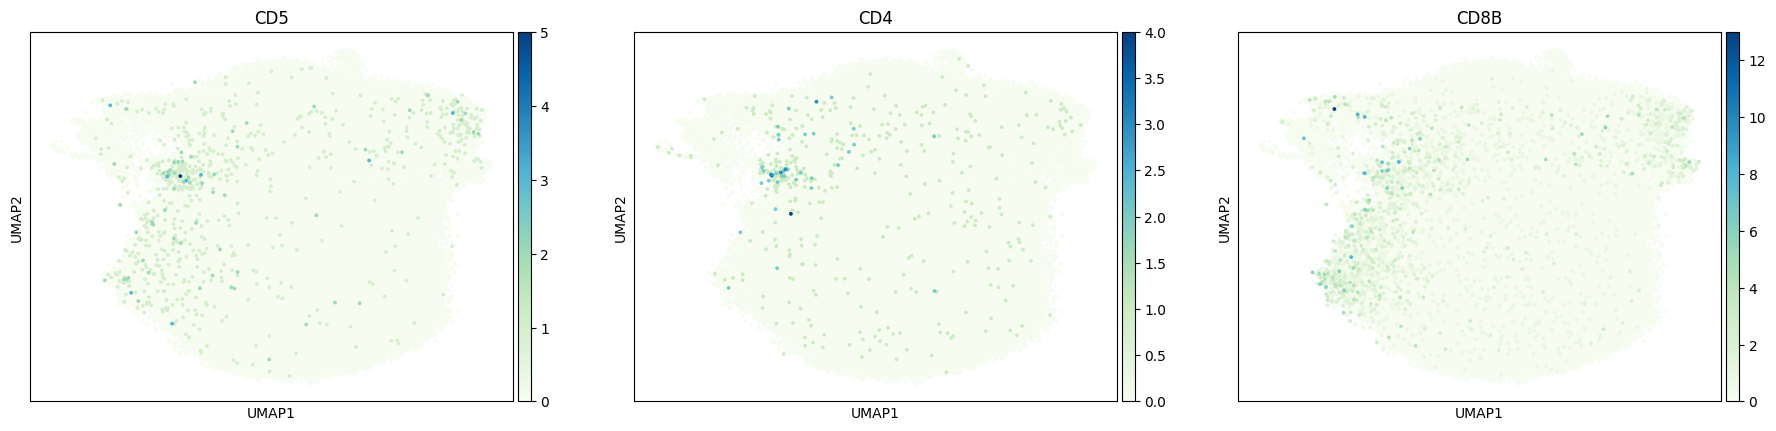

In [111]:
sc.pl.umap(adata, color=["CD5", "CD4", "CD8B"],
           cmap='GnBu', ncols=4, 
           show=False, size=30)

plt.show()

# Removal of T cells

In [113]:
# Define T-cell marker genes
genes_of_interest = ['CD5', 'CD4', 'CD8B']

# Ensure those genes exist in your data
genes_present = [g for g in genes_of_interest if g in adata.var_names]
print(f"Found genes: {genes_present}")

if not genes_present:
    raise ValueError("None of the target genes found in adata_v4.var_names")

# Extract expression values for those genes
X_sub = adata[:, genes_present].X

# Convert to dense array if sparse
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()

# Create boolean mask for T cells (any of the marker genes ≥ 1)
is_tcell = np.any(X_sub >= 1, axis=1)

# Filter out T cells
adata_filtered = adata[~is_tcell].copy()

print(f"Original cells: {adata.n_obs}")
print(f"Remaining cells (non-T): {adata_filtered.n_obs}")

Found genes: ['CD5', 'CD4', 'CD8B']
Original cells: 85505
Remaining cells (non-T): 82408


In [120]:
adata_filtered.obs

,sample,batch,subset,dataset,source,total_counts,n_genes_by_counts,pct_counts_mt,_scvi_batch,_scvi_labels,...,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc,HALLMARK_GLYCOLYSIS_auc,HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc,subset_source,bright_dim_subset,reference,Malmberg_patient,patient_ID,dataset_v2,patient_ID_v2
AAACCTGAGTGTCCAT_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1345.0,725.0,2.304833,401,0,...,0.098046,0.041626,0.005439,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1
AAACCTGCACATGGGA_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,2108.0,884.0,2.182163,401,0,...,0.106493,0.033480,0.000000,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1
AAACCTGCACCTCGGA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1821.0,853.0,2.471170,401,0,...,0.093315,0.054942,0.000000,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1
AAACCTGGTTGAGTTC_1-0,malm1,malm1_bulk,NKG2A+,malm,PBMC,1294.0,753.0,2.086553,401,0,...,0.126957,0.041032,0.018933,NKG2A+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1
AAACCTGTCACCGTAA_1-0,malm1,malm1_bulk,KIR+,malm,PBMC,1637.0,831.0,1.710446,401,0,...,0.122799,0.035483,0.013773,KIR+_PBMC,CD56dim,reference,malm1,malm1,malm,malm1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rGBM-04-4_TAAGTCGGTTCTTGCC-1-0-1_abdelfattah_rGBM-04,rGBM-04,rGBM-04,TiCD56bright,abdelfattah,glioblastoma,2693.0,1184.0,3.564798,843,0,...,0.079250,0.028977,0.000000,TiCD56bright_glioblastoma,CD56bright,tumor,rGBM-04_abdelfattah,rGBM-04_abdelfattah,abdelfattah,rGBM-04_abdelfattah
rGBM-05-2_ATATCCTAGTCATACC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,1946.0,1059.0,1.593011,844,0,...,0.109973,0.055180,0.026290,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah
rGBM-05-2_CCCTCAACATAGACTC-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,2335.0,1371.0,2.655246,844,0,...,0.084738,0.038762,0.006032,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah
rGBM-05-3_AGGAAATCATTCATCT-1-0-1_abdelfattah_rGBM-05,rGBM-05,rGBM-05,TiCD56dim,abdelfattah,glioblastoma,5610.0,1888.0,8.039216,844,0,...,0.129551,0.034727,0.000000,TiCD56dim_glioblastoma,CD56dim,tumor,rGBM-05_abdelfattah,rGBM-05_abdelfattah,abdelfattah,rGBM-05_abdelfattah


In [119]:
adata_filtered

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [115]:
adata_filtered.obs["dataset_v2"].value_counts()

dataset_v2
amir           13086
leader          9102
kim             8205
bischoff        6403
he_D            5643
chan            4261
crinier         3961
malm            3210
lambrechts      2962
chen_J          2902
yang            2863
zhang           2628
pombo           2613
wu_S            2122
leader_cite     1815
pal             1800
abdelfattah     1315
bassez          1019
cillo           1016
steele           988
chen_K           681
bhat             603
liu              532
ravi             489
lee              462
heidegger        350
chen_S           277
richards         178
tuong            168
goswami           86
smalley           86
couturier         83
peng              82
rindler           76
zhou              73
mirizio           63
xue               48
he_Y              45
mathewson         34
damsky            25
neftel            24
johnson           17
lin                8
wang2020           3
wang2019           1
Name: count, dtype: int64

In [116]:
adata_filtered.obs["patient_ID_v2"].value_counts()

patient_ID_v2
amir5         4584
amir6         2798
amir8         2597
CM1_zhang     2567
amir4         1991
              ... 
GSM5788501       1
T8_peng          1
P09_lin          1
N7_peng          1
BC2_zhou         1
Name: count, Length: 412, dtype: int64

In [117]:
#adata_filtered.write_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/Malmberg_v4_fil_non10X_Datasetv2_PatientIDv2_nonNKremoval_adata_TcellFiltered.h5ad")

In [118]:
#adata_filtered.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/Malmberg_v4_fil_non10X_Datasetv2_PatientIDv2_nonNKremoval_adata_TcellFiltered.csv")